<a href="https://colab.research.google.com/github/yunseoplee133-stack/GLP-1/blob/main/GLP_1_Machine_Learning_(Bootstrap_%EC%97%86%EB%8A%94_%EB%B2%84%EC%A0%84)%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

Saving ML_Ready_Final_FAERS_Train.csv to ML_Ready_Final_FAERS_Train.csv


In [ ]:
# 데이터 크기 확인용 코드
print("test_input 행 개수:", test_input.shape[0])
print("test_target 행 개수:", test_target.shape[0])

test_input 행 개수: 5777
test_target 행 개수: 1081


In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
file_name = 'ML_Ready_Final_FAERS_Train.csv'
data = pd.read_csv(file_name)
print(data.head())

   RFU_Product used for unknown indication  RFU_Type 2 diabetes mellitus  \
0                                     2256                          1355   
1                                     4368                          2568   
2                                     2186                          1426   
3                                      447                           314   
4                                      624                           246   

   RFU_Diabetes mellitus  RFU_Weight decreased  \
0                    483                   278   
1                    804                   483   
2                    482                   230   
3                    109                    65   
4                    120                    30   

   RFU_Glucose tolerance impaired  RFU_Weight control  RFU_Obesity  \
0                              93                 154          139   
1                             240                 272          190   
2                              9

In [ ]:
#BRF 모델 분석

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# 📌 1. SOC Type 전처리 (기존과 동일)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
soc_onehot = encoder.fit_transform(data[['SOC']])
pca = PCA(n_components=5, random_state=42)
soc_pca = pca.fit_transform(soc_onehot)
soc_pca_df = pd.DataFrame(soc_pca, columns=['SOCPC a', 'SOCPC b', 'SOCPC c','SOCPC d', 'SOCPC e'])

# 📌 데이터 준비
input_columns = ['Feature a','Feature b','Feature c','Feature d',
    'RFU_Product used for unknown indication', 'RFU_Type 2 diabetes mellitus',
    'RFU_Weight decreased','RFU_Glucose tolerance impaired','RFU_Weight control','RFU_Obesity','RFU_Hypertension',
    'RFU_Glycosylated haemoglobin increased','RFU_Insulin resistance','RFU_Blood glucose increased',
    'RFU_Blood glucose abnormal','RFU_Type 1 diabetes mellitus','RFU_Overweight',
    'RFU_Blood cholesterol increased', 'RFU_Depression',
    'RFU_Pain', "RFU_Cushing's syndrome", 'RFU_Blood cholesterol', 'RFU_Gastrooesophageal reflux disease',
    'RFU_Glycosylated haemoglobin', 'RFU_Cardiac disorder', 'RFU_Blood pressure measurement',
    'RFU_Anxiety', 'RFU_Hypothyroidism', 'RFU_Blood cholesterol abnormal', 'RFU_Blood pressure abnormal',
    'RFU_Thyroid disorder', 'RFU_Asthma',
    'Outcome_Congenital_Anomaly','Outcome_Died','Outcome_Disabled','Outcome_Hospitalized','OT',
    'Outcome_Required_Intervention','Serious','Non_Serious',
    'Sex_F','Sex_M','Male+Female', 'Sex_UNK','Reporter_CN','Reporter_HP',
    'Reporter_LW','Reporter_MD','Reporter_PH','Continent_Africa','Continent_Asia','Continent_Europe',
    'Continent_North America','Continent_Oceania','Continent_Other_Continent','Continent_South America',
    'Age_Age_0_20','Age_Age_21_40','Age_Age_41_60','Age_Age_61_Plus',
    'Weight_Weight_0_60','Weight_Weight_61_80','Weight_Weight_81_100','Weight_Weight_101_Plus',
    'Drug_dulaglutide','Drug_exenatide','Drug_liraglutide','Drug_lixisenatide','Drug_semaglutide','Drug_tirzepatide']

X_main = data[input_columns].reset_index(drop=True)
X_final = pd.concat([X_main, soc_pca_df], axis=1)
y = data['adr_type'].to_numpy()

# 📌 3. Train/Test 데이터 분할 (Stratified 적용으로 비율 유지)
train_input, test_input, train_target, test_target = train_test_split(
    X_final.to_numpy(), y, test_size=0.35, stratify=y, random_state=42
)

# Target 변환 (1 = Positive, 2 = Negative -> 1, 0으로 변환)
train_target = (train_target == 1).astype(int)
test_target = (test_target == 1).astype(int)

# 📌 4. Train 데이터에만 SMOTE 적용 (Test는 절대 건드리지 않음!)
smote = SMOTE(sampling_strategy=0.2, random_state=42)
train_input_resampled, train_target_resampled = smote.fit_resample(train_input, train_target)

# 📌 5. Balanced Random Forest 모델 학습
brf = BalancedRandomForestClassifier(
    random_state=42, max_depth=None, sampling_strategy='auto', class_weight="balanced"
)
brf.fit(train_input_resampled, train_target_resampled)

# ❌ (삭제됨) 테스트 세트 Bootstrap 증강 코드 완전 제거 ❌
# 현실 세계의 데이터 분포를 그대로 유지하여 평가해야 합니다.

# 📌 6. 깨끗한 Test Set으로 예측 확률 계산
y_proba = brf.predict_proba(test_input)[:, 1]

# 📌 7. 최적의 임계값(Threshold) 찾기 (오직 원본 Test 데이터만 사용)
precision, recall, thresholds = precision_recall_curve(test_target, y_proba)
# 분모가 0이 되는 것을 방지하기 위해 1e-9 추가
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

# 📌 8. 예측 수행 (기본 0.5 vs 최적값 vs 커스텀 0.1)
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
y_pred_custom = (y_proba >= 0.1).astype(int)

# 📌 9. 진짜 성능 평가 (Classification Report & PR-AUC)
print("=== 진짜 실력 평가 결과 (원본 Test Data) ===")

print(f"\n[1] 기본 Threshold (0.5) 결과:")
print(classification_report(test_target, y_pred_default))

print(f"\n[2] 최적 Threshold ({optimal_threshold:.3f}) 결과:")
print(classification_report(test_target, y_pred_optimal))

print(f"\n[3] 커스텀 Threshold (0.1) 결과:")
print(classification_report(test_target, y_pred_custom))

pr_auc = average_precision_score(test_target, y_proba)
print(f"\n💡 PR-AUC 점수 (불균형 데이터 핵심 지표): {pr_auc:.4f}")

# 📌 (보너스) Stratified K-Fold로 모델의 안정성 검증
# 테스트 세트 하나에만 의존하지 않고, 모델이 전반적으로 얼마나 안정적인지 확인합니다.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(brf, X_final.to_numpy(), (y == 1).astype(int), cv=cv, scoring='average_precision')
print(f"\n🔍 5-Fold 교차 검증 PR-AUC 평균 점수: {cv_scores.mean():.4f}")


=== 진짜 실력 평가 결과 (원본 Test Data) ===

[1] 기본 Threshold (0.5) 결과:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1336
           1       0.28      0.56      0.37        41

    accuracy                           0.94      1377
   macro avg       0.63      0.76      0.67      1377
weighted avg       0.97      0.94      0.95      1377


[2] 최적 Threshold (0.610) 결과:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1336
           1       0.36      0.51      0.42        41

    accuracy                           0.96      1377
   macro avg       0.67      0.74      0.70      1377
weighted avg       0.97      0.96      0.96      1377


[3] 커스텀 Threshold (0.1) 결과:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1336
           1       0.12      0.85      0.21        41

    accuracy                           0.81      1377
   mac

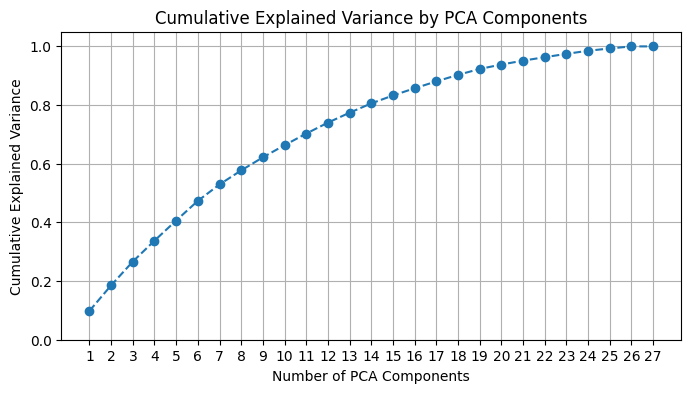

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np

# 1. One-hot 인코딩
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
soc_onehot = encoder.fit_transform(data[['SOC']])

# 2. PCA (차원 수 크게 해서 분석)
pca = PCA(n_components=27, random_state=42)
pca_result = pca.fit_transform(soc_onehot)

# 3. 설명 분산 비율 확인
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# 4. 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.xticks(range(1, len(explained_var)+1))
plt.ylim(0, 1.05)
plt.show()

ROC-AUC Score: 0.9069


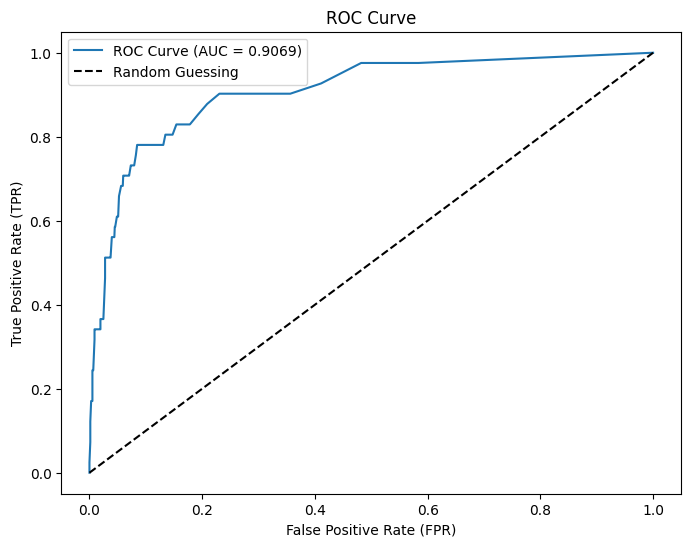

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# ROC-AUC 점수
auc_score = roc_auc_score(test_target, y_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")
# ROC 곡선 시각화
fpr, tpr, thresholds = roc_curve(test_target, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print(input.head())

AttributeError: 'function' object has no attribute 'head'

/tmp/ipykernel_3240/4194431222.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


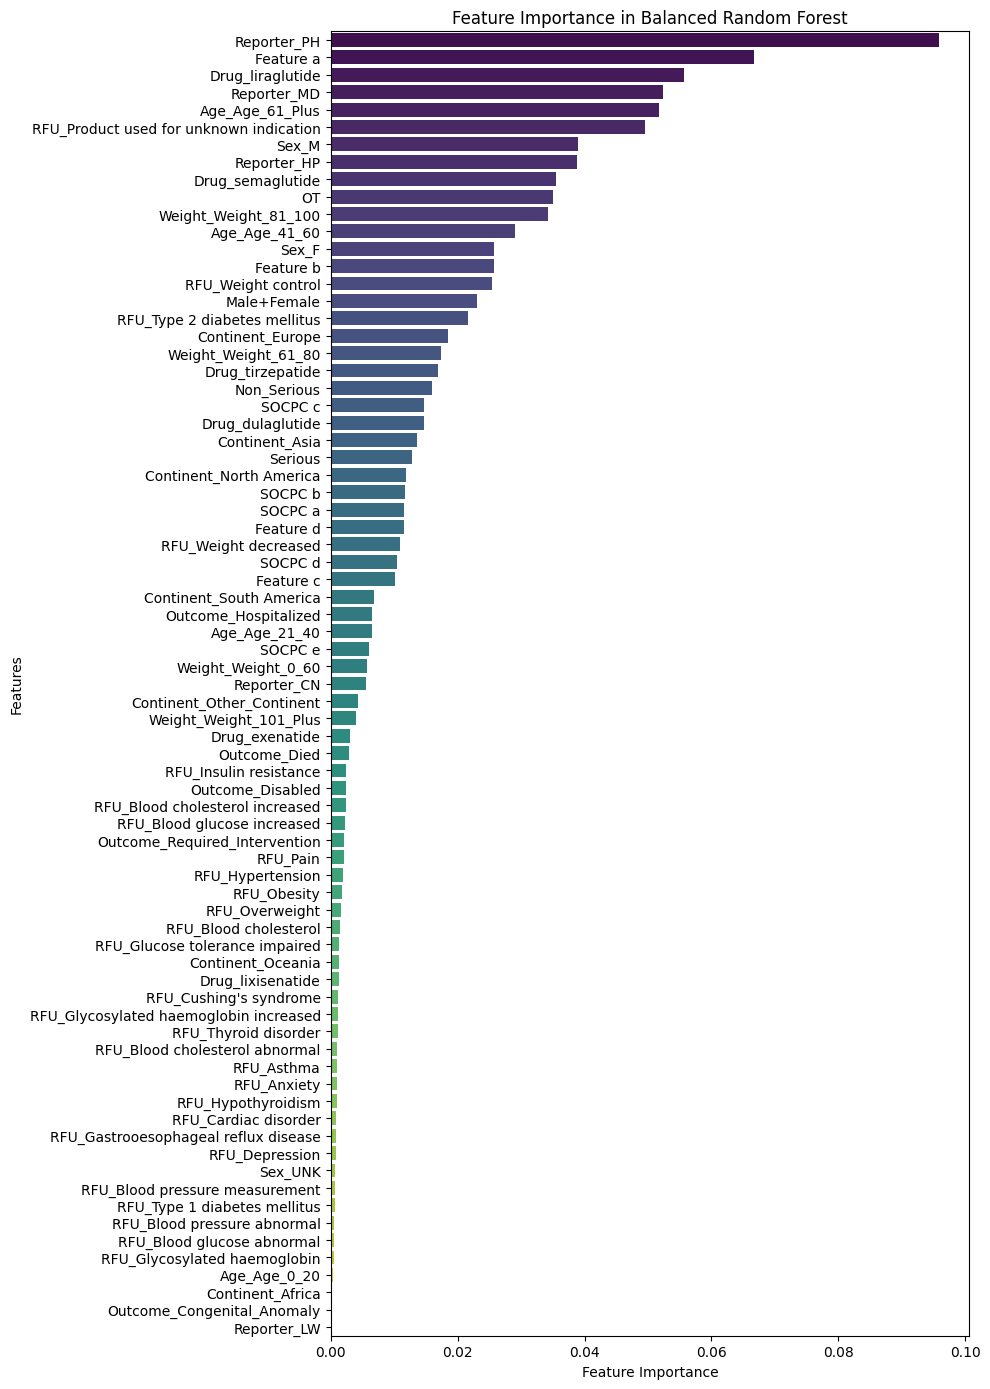


🔍 [ PCA 주성분(PC) 해석 표 ]


,SOC_0,SOC_1,SOC_2,SOC_3,SOC_4,SOC_5,SOC_6,SOC_7,SOC_8,SOC_9,...,SOC_17,SOC_18,SOC_19,SOC_20,SOC_21,SOC_22,SOC_23,SOC_24,SOC_25,SOC_27
SOCPC a,-0.004924,-0.009976,-0.003688,-0.002175,-0.003393,-0.019548,-0.248040,-0.059187,-0.007089,-0.003688,...,-0.002357,-0.008216,-0.028479,-0.009008,-0.013206,-0.018678,-0.021869,-0.004192,-0.024970,-0.008740
SOCPC b,-0.001915,-0.003972,-0.001426,-0.000835,-0.001310,-0.008152,0.784426,-0.030716,-0.002785,-0.001426,...,-0.000906,-0.003244,-0.012427,-0.003570,-0.005340,-0.007756,-0.009227,-0.001625,-0.010702,-0.003460
SOCPC c,-0.008528,-0.017986,-0.006326,-0.003688,-0.005807,-0.038221,0.477056,-0.177999,-0.012488,-0.006326,...,-0.004001,-0.014604,-0.060450,-0.016114,-0.024453,-0.036242,-0.043655,-0.007218,-0.051278,-0.015601
SOCPC d,-0.003118,-0.006808,-0.002295,-0.001326,-0.002103,-0.015644,0.063567,-0.166323,-0.004632,-0.002295,...,-0.001440,-0.005459,-0.027170,-0.006057,-0.009483,-0.014717,-0.018267,-0.002627,-0.022151,-0.005853
SOCPC e,-0.002118,-0.004679,-0.001554,-0.000895,-0.001423,-0.011069,0.035550,-0.237545,-0.003161,-0.001554,...,-0.000972,-0.003735,-0.019997,-0.004153,-0.006575,-0.010381,-0.013040,-0.001781,-0.016023,-0.004010


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NumPy 출력 옵션 설정
np.set_printoptions(suppress=True, precision=6)

# 📌 전체 특성 이름 (SOC 포함)
soc_pca_columns = ['SOCPC a', 'SOCPC b', 'SOCPC c','SOCPC d', 'SOCPC e'
                   ]

# input_columns는 기존 공변량 이름 리스트 (X_main 구성 요소)
feature_names = input_columns + soc_pca_columns  # input_columns는 앞에서 정의한 리스트

# 📌 특성 중요도 벡터
feature_importances = brf.feature_importances_

# 📌 중요도 기준 정렬
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = np.array(feature_names)[sorted_idx]

# 📌 시각화
plt.figure(figsize=(10, 14))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Balanced Random Forest")
plt.tight_layout()
plt.show()

# 📌 PCA 컴포넌트 해석
soc_feature_names = encoder.get_feature_names_out(['SOC'])

# ⭐ [핵심 수정] pca.components_[:5, :] 를 사용하여 딱 5줄만 가져오도록 강제합니다.
pca_components = pd.DataFrame(pca.components_[:5, :], columns=soc_feature_names, index=soc_pca_columns)

print("\n🔍 [ PCA 주성분(PC) 해석 표 ]")
display(pca_components.head())

In [ ]:
uploaded = files.upload()

Saving ML_Ready_Final_FAERS_Test.csv to ML_Ready_Final_FAERS_Test (1).csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from google.colab import files

# ✅ 원본 test 데이터 로드
data2 = pd.read_csv('ML_Ready_Final_FAERS_Test.csv')

# ✅ SOC Type → One-hot 인코딩 후 PCA
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
soc_onehot = encoder.fit_transform(data2[['SOC']])
pca = PCA(n_components=5, random_state=42)
soc_pca = pca.fit_transform(soc_onehot)

# ✅ SOC PCA 컬럼 추가
soc_pca_columns = ['SOCPC a', 'SOCPC b', 'SOCPC c','SOCPC d', 'SOCPC e']
soc_pca_df = pd.DataFrame(soc_pca, columns=soc_pca_columns)
data2 = pd.concat([data2.reset_index(drop=True), soc_pca_df], axis=1)

# ✅ 모델 학습과 동일한 Feature 리스트
feature_columns = ['Feature a','Feature b','Feature c','Feature d',
    'RFU_Product used for unknown indication', 'RFU_Type 2 diabetes mellitus',
    'RFU_Weight decreased','RFU_Glucose tolerance impaired','RFU_Weight control','RFU_Obesity','RFU_Hypertension',
    'RFU_Glycosylated haemoglobin increased','RFU_Insulin resistance','RFU_Blood glucose increased',
    'RFU_Blood glucose abnormal','RFU_Type 1 diabetes mellitus','RFU_Overweight',
    'RFU_Blood cholesterol increased', 'RFU_Depression',
    'RFU_Pain', "RFU_Cushing's syndrome", 'RFU_Blood cholesterol', 'RFU_Gastrooesophageal reflux disease',
    'RFU_Glycosylated haemoglobin', 'RFU_Cardiac disorder', 'RFU_Blood pressure measurement',
    'RFU_Anxiety', 'RFU_Hypothyroidism', 'RFU_Blood cholesterol abnormal', 'RFU_Blood pressure abnormal',
    'RFU_Thyroid disorder', 'RFU_Asthma',
    'Outcome_Congenital_Anomaly','Outcome_Died','Outcome_Disabled','Outcome_Hospitalized','OT',
    'Outcome_Required_Intervention','Serious','Non_Serious',
    'Sex_F','Sex_M','Male+Female', 'Sex_UNK','Reporter_CN','Reporter_HP',
    'Reporter_LW','Reporter_MD','Reporter_PH','Continent_Africa','Continent_Asia','Continent_Europe',
    'Continent_North America','Continent_Oceania','Continent_Other_Continent','Continent_South America',
    'Age_Age_0_20','Age_Age_21_40','Age_Age_41_60','Age_Age_61_Plus',
    'Weight_Weight_0_60','Weight_Weight_61_80','Weight_Weight_81_100','Weight_Weight_101_Plus',
    'Drug_dulaglutide','Drug_exenatide','Drug_liraglutide','Drug_lixisenatide','Drug_semaglutide','Drug_tirzepatide'] + soc_pca_columns

# ✅ 입력 데이터 생성
test_input = data2[feature_columns].to_numpy()

# ✅ 예측
y_proba = brf.predict_proba(test_input)[:, 1]
optimal_threshold = 0.50
y_pred = (y_proba >= optimal_threshold).astype(int)

# ✅ 결과 저장
results = pd.DataFrame({
    'Predicted_Label': y_pred,
    'Prediction_Probability': y_proba
})
output_file = "predictions.xlsx"
results.to_excel(output_file, index=False)
files.download(output_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#SHAP 분석

⏳ SHAP 값을 계산 중입니다. 트리를 다 뒤져야 해서 몇 초 정도 걸릴 수 있습니다...


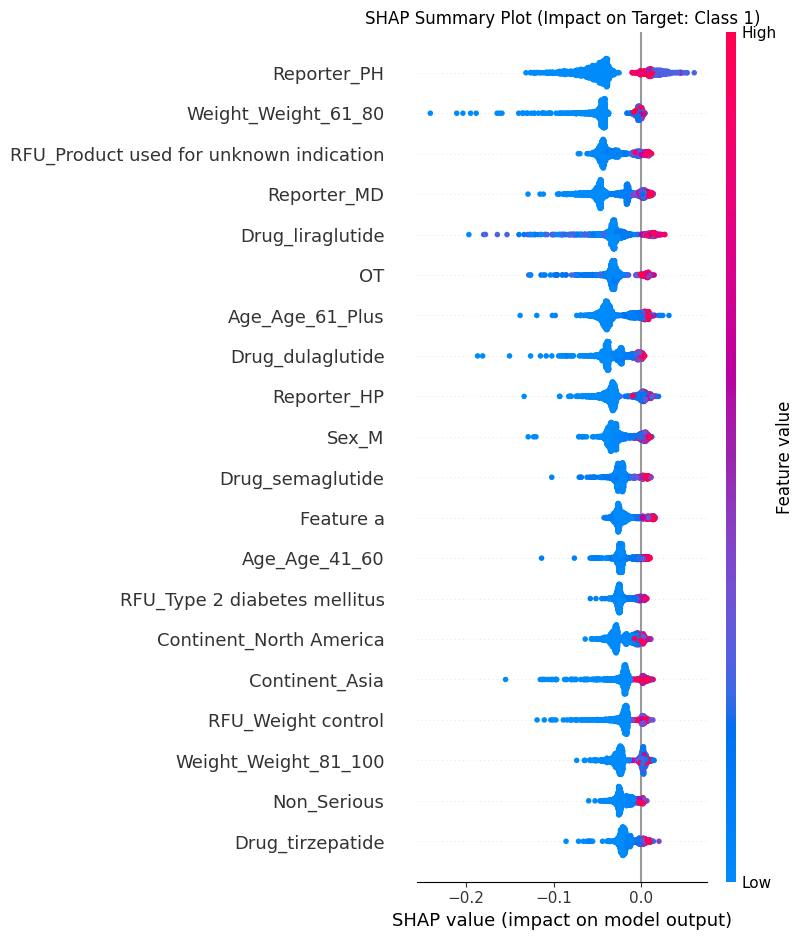

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# 📌 1. 까먹은 이름표(feature_names) 다시 확실하게 정의하기
input_columns = ['Feature a','Feature b','Feature c','Feature d',
    'RFU_Product used for unknown indication', 'RFU_Type 2 diabetes mellitus',
    'RFU_Weight decreased','RFU_Glucose tolerance impaired','RFU_Weight control','RFU_Obesity','RFU_Hypertension',
    'RFU_Glycosylated haemoglobin increased','RFU_Insulin resistance','RFU_Blood glucose increased',
    'RFU_Blood glucose abnormal','RFU_Type 1 diabetes mellitus','RFU_Overweight',
    'RFU_Blood cholesterol increased', 'RFU_Depression',
    'RFU_Pain', "RFU_Cushing's syndrome", 'RFU_Blood cholesterol', 'RFU_Gastrooesophageal reflux disease',
    'RFU_Glycosylated haemoglobin', 'RFU_Cardiac disorder', 'RFU_Blood pressure measurement',
    'RFU_Anxiety', 'RFU_Hypothyroidism', 'RFU_Blood cholesterol abnormal', 'RFU_Blood pressure abnormal',
    'RFU_Thyroid disorder', 'RFU_Asthma',
    'Outcome_Congenital_Anomaly','Outcome_Died','Outcome_Disabled','Outcome_Hospitalized','OT',
    'Outcome_Required_Intervention','Serious','Non_Serious',
    'Sex_F','Sex_M','Male+Female', 'Sex_UNK','Reporter_CN','Reporter_HP',
    'Reporter_LW','Reporter_MD','Reporter_PH','Continent_Africa','Continent_Asia','Continent_Europe',
    'Continent_North America','Continent_Oceania','Continent_Other_Continent','Continent_South America',
    'Age_Age_0_20','Age_Age_21_40','Age_Age_41_60','Age_Age_61_Plus',
    'Weight_Weight_0_60','Weight_Weight_61_80','Weight_Weight_81_100','Weight_Weight_101_Plus',
    'Drug_dulaglutide','Drug_exenatide','Drug_liraglutide','Drug_lixisenatide','Drug_semaglutide','Drug_tirzepatide']

soc_pca_columns = ['SOCPC a', 'SOCPC b', 'SOCPC c','SOCPC d', 'SOCPC e']

# 두 리스트를 합쳐서 최종 이름표 완성!
feature_names = input_columns + soc_pca_columns

# 📌 2. 테스트 데이터를 DataFrame으로 변환 (이름표 달아주기)
test_df = pd.DataFrame(test_input, columns=feature_names)

# 📌 3. SHAP Explainer 초기화 및 계산
explainer = shap.TreeExplainer(brf)
print("⏳ SHAP 값을 계산 중입니다. 트리를 다 뒤져야 해서 몇 초 정도 걸릴 수 있습니다...")
shap_values = explainer.shap_values(test_df)

# [주의 처리] 이진 분류의 경우 Class 1(부작용 발생)에 대한 데이터만 쏙 빼옵니다.
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

# 📌 4. SHAP Summary Plot 시각화
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Impact on Target: Class 1)")
shap.summary_plot(shap_values_class1, test_df, max_display=20)
plt.show()

In [ ]:
# <로지스틱회귀분석>

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# 1. 📥 데이터 로드
df = pd.read_csv('ML_Ready_Final_FAERS_Train.csv')

# 2. Target 정의 (결측치 안전 처리)
df['Label'] = df['adr_type'].fillna(0).astype(int)
y = df['Label']

# 3. logROR 계산
epsilon = 0.5
df['logROR'] = np.log((df['Feature a'] + epsilon) * (df['Feature d'] + epsilon)) - \
               np.log((df['Feature b'] + epsilon) * (df['Feature c'] + epsilon))

# 4. Age group → one-hot
age_columns = ['Age_Age_0_20', 'Age_Age_21_40', 'Age_Age_41_60', 'Age_Age_61_Plus']
df['Age_Group'] = df[age_columns].idxmax(axis=1)
age_dummies = pd.get_dummies(df['Age_Group'], prefix='Age')

# 5. 스케일링
scale_vars = ['logROR', 'Reporter_CN','Reporter_HP','Reporter_LW','Reporter_MD','Reporter_PH',
              'Sex_F', 'Sex_M', 'Male+Female', 'Sex_UNK']
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[scale_vars])
scaled_df = pd.DataFrame(scaled_array, columns=[f"{col}_scaled" for col in scale_vars])

# 6. SOC Type → One-hot → PCA(5D)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
soc_onehot = encoder.fit_transform(df[['SOC']])
pca = PCA(n_components=5, random_state=42)
soc_pca = pca.fit_transform(soc_onehot)
soc_pca_df = pd.DataFrame(soc_pca, columns=[f'SOCPC {c}' for c in 'abcde'])

# 7. 최종 X 구성
X = pd.concat([scaled_df.reset_index(drop=True), age_dummies.reset_index(drop=True), soc_pca_df.reset_index(drop=True)], axis=1)

# 8. Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.35, random_state=42)

# 9. SMOTE 적용 (Train에만 적용하여 불균형 해소)
smote = SMOTE(random_state=42, sampling_strategy=0.2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 10. 모델 학습
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train_resampled, y_train_resampled)

# ✅ 11. (수정됨) 부트스트랩(테스트셋 뻥튀기) 완전 제거. 원본 Test 데이터만 사용.

# 12. 예측 및 평가 (거품 없는 순수 테스트셋 사용)
probs = model.predict_proba(X_test)[:, 1]

# Threshold 설정
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Predict
preds = (probs >= best_threshold).astype(int)
auc = roc_auc_score(y_test, probs)
pr_auc = average_precision_score(y_test, probs)

# 13. Adjusted Odds Ratio for logROR
logror_scaled_idx = X.columns.get_loc('logROR_scaled')
beta = model.coef_[0][logror_scaled_idx]
aROR = np.exp(beta)

# 14. 출력
print("\n📄 Classification Report (Clean Test Set - No Bootstrap):")
print(classification_report(y_test, preds, digits=2))
print("\n✅ 최종 모델 성능 요약:")
print(f"- ROC AUC: {auc:.4f}")
print(f"- PR AUC: {pr_auc:.4f}")
print(f"- F1-score 최대 임계값: {best_threshold:.4f}")
print(f"- F1-score: {best_f1:.3f}")
print(f"▶ Adjusted Odds Ratio (aROR) for logROR (scaled): {aROR:.4f}")

# 15. 저장 (파일 이름도 헷갈리지 않게 Clean으로 변경)
final_df = X_test.copy()
final_df['Label'] = y_test
final_df['Predicted_Probability'] = probs
final_df['Predicted_Label'] = preds
final_df.to_csv('Final_LogReg_Predictions_Clean.csv', index=False)



📄 Classification Report (Clean Test Set - No Bootstrap):
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1336
           1       0.52      0.56      0.54        41

    accuracy                           0.97      1377
   macro avg       0.75      0.77      0.76      1377
weighted avg       0.97      0.97      0.97      1377


✅ 최종 모델 성능 요약:
- ROC AUC: 0.8973
- PR AUC: 0.4158
- F1-score 최대 임계값: 0.4272
- F1-score: 0.541
▶ Adjusted Odds Ratio (aROR) for logROR (scaled): 1.1904


✅ BRF 예측값 생성 완료! (AUC: 0.9069)
✅ Logistic 파일 로드 완료! (AUC: 0.8973)


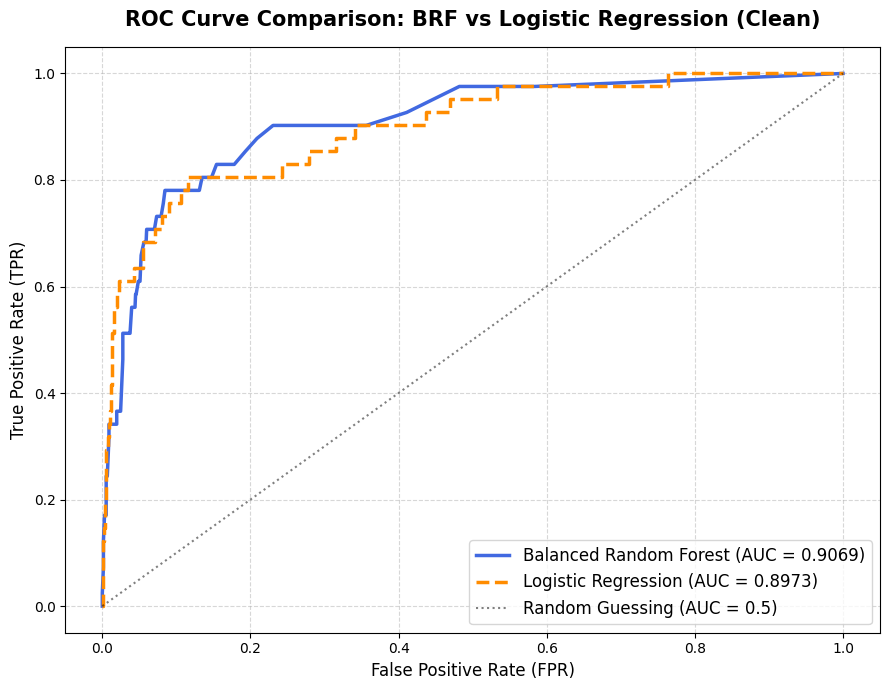

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 🛠️ 1. BRF 모델 평가 (거품 뺀 Clean 원본 데이터 사용)
# =======================================================
try:
    # 📌 _aug 가 붙지 않은 순수 원본(test_input, test_target) 사용
    y_proba_brf = brf.predict_proba(test_input)[:, 1]

    fpr_brf, tpr_brf, _ = roc_curve(test_target, y_proba_brf)
    auc_brf = roc_auc_score(test_target, y_proba_brf)
    print(f"✅ BRF 예측값 생성 완료! (AUC: {auc_brf:.4f})")
except NameError:
    print("❌ 에러: 'brf' 모델이나 원본 데이터가 기억상실 상태입니다!")
    print("👉 해결책: 스크롤을 위로 올려서 [BRF 모델 학습 코드]를 한 번만 실행하고 다시 와주세요.")
    auc_brf = 0

# =======================================================
# 🛠️ 2. 로지스틱 회귀 (Clean 파일 로드)
# =======================================================
try:
    logit_df = pd.read_csv('Final_LogReg_Predictions_Clean.csv')
    y_true_logit = logit_df['Label'].astype(int)
    y_score_logit = logit_df['Predicted_Probability']

    fpr_logit, tpr_logit, _ = roc_curve(y_true_logit, y_score_logit)
    auc_logit = roc_auc_score(y_true_logit, y_score_logit)
    print(f"✅ Logistic 파일 로드 완료! (AUC: {auc_logit:.4f})")
except FileNotFoundError:
    print("❌ 에러: 'Final_LogReg_Predictions_Clean.csv' 파일이 없습니다.")
    auc_logit = 0

# =======================================================
# 🎨 3. 두 모델의 ROC 커브 겹쳐서 그리기
# =======================================================
if auc_brf > 0 and auc_logit > 0:
    plt.figure(figsize=(9, 7))

    # BRF Plot (파란색 실선)
    plt.plot(fpr_brf, tpr_brf, label=f"Balanced Random Forest (AUC = {auc_brf:.4f})",
             color='royalblue', linewidth=2.5)

    # Logistic Plot (주황색 점선)
    plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC = {auc_logit:.4f})",
             color='darkorange', linestyle='--', linewidth=2.5)

    # Random Guessing (대각선)
    plt.plot([0, 1], [0, 1], 'k:', label="Random Guessing (AUC = 0.5)", alpha=0.5)

    # 디자인
    plt.xlabel("False Positive Rate (FPR)", fontsize=12)
    plt.ylabel("True Positive Rate (TPR)", fontsize=12)
    plt.title("ROC Curve Comparison: BRF vs Logistic Regression (Clean)",
              fontsize=15, fontweight='bold', pad=15)

    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show()

In [ ]:
#GBM 모델분석

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

# 📌 SOC Type 처리: One-hot → PCA
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
soc_onehot = encoder.fit_transform(data[['SOC']])
pca = PCA(n_components=5, random_state=42)
soc_pca = pca.fit_transform(soc_onehot)
soc_pca_df = pd.DataFrame(soc_pca, columns=['SOCPC a', 'SOCPC b', 'SOCPC c', 'SOCPC d', 'SOCPC e'])

# 📌 주요 입력 변수 리스트
input_columns = ['Feature a','Feature b','Feature c','Feature d',
    'RFU_Product used for unknown indication', 'RFU_Type 2 diabetes mellitus',
    'RFU_Weight decreased','RFU_Glucose tolerance impaired','RFU_Weight control','RFU_Obesity','RFU_Hypertension',
    'RFU_Glycosylated haemoglobin increased','RFU_Insulin resistance','RFU_Blood glucose increased',
    'RFU_Blood glucose abnormal','RFU_Type 1 diabetes mellitus','RFU_Overweight',
    'RFU_Blood cholesterol increased', 'RFU_Depression',
    'RFU_Pain', "RFU_Cushing's syndrome", 'RFU_Blood cholesterol', 'RFU_Gastrooesophageal reflux disease',
    'RFU_Glycosylated haemoglobin', 'RFU_Cardiac disorder', 'RFU_Blood pressure measurement',
    'RFU_Anxiety', 'RFU_Hypothyroidism', 'RFU_Blood cholesterol abnormal', 'RFU_Blood pressure abnormal',
    'RFU_Thyroid disorder', 'RFU_Asthma',
    'Outcome_Congenital_Anomaly','Outcome_Died','Outcome_Disabled','Outcome_Hospitalized','OT',
    'Outcome_Required_Intervention','Serious','Non_Serious',
    'Sex_F','Sex_M','Male+Female', 'Sex_UNK','Reporter_CN','Reporter_HP',
    'Reporter_LW','Reporter_MD','Reporter_PH','Continent_Africa','Continent_Asia','Continent_Europe',
    'Continent_North America','Continent_Oceania','Continent_Other_Continent','Continent_South America',
    'Age_Age_0_20','Age_Age_21_40','Age_Age_41_60','Age_Age_61_Plus',
    'Weight_Weight_0_60','Weight_Weight_61_80','Weight_Weight_81_100','Weight_Weight_101_Plus',
    'Drug_dulaglutide','Drug_exenatide','Drug_liraglutide','Drug_lixisenatide','Drug_semaglutide','Drug_tirzepatide']

# 📌 데이터 준비
X_main = data[input_columns].reset_index(drop=True)
X_final = pd.concat([X_main, soc_pca_df], axis=1)
y = data['adr_type'].to_numpy()

# 📌 Train/Test Split
train_input, test_input, train_target, test_target = train_test_split(
    X_final.to_numpy(), y, test_size=0.35, stratify=y, random_state=42
)

# 📌 SMOTE 적용
smote = SMOTE(sampling_strategy=0.2, random_state=42)
train_input_resampled, train_target_resampled = smote.fit_resample(train_input, train_target)

# 📌 Label 변환
train_target_resampled = (train_target_resampled == 1).astype(int)
test_target = (test_target == 1).astype(int)

# ✅ GBM 모델 학습
gbm = XGBClassifier(
    random_state=42,
    max_depth=5,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)
gbm.fit(train_input_resampled, train_target_resampled)


# 📌 예측
y_proba = gbm.predict_proba(test_input)[:, 1]
y_pred = (y_proba >= 0.32).astype(int)

# 📌 Precision-Recall 기반 Threshold 최적화
precision, recall, thresholds = precision_recall_curve(test_target, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

# 📌 Custom Threshold (0.1)
custom_threshold = 0.1
y_pred_custom = (y_proba >= custom_threshold).astype(int)

# 📌 평가 결과 출력
print("Classification Report with Default Threshold (0.32):")
print(classification_report(test_target, y_pred))

print(f"Optimal Threshold: {optimal_threshold}")
print("Classification Report with Optimal Threshold:")
print(classification_report(test_target, y_pred_optimal))

print("Classification Report with Custom Threshold (0.1):")
print(classification_report(test_target, y_pred_custom))

pr_auc = average_precision_score(test_target, y_proba)
print("PR-AUC Score:", pr_auc)


Classification Report with Default Threshold (0.32):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1336
           1       0.52      0.39      0.44        41

    accuracy                           0.97      1377
   macro avg       0.75      0.69      0.71      1377
weighted avg       0.97      0.97      0.97      1377

Optimal Threshold: 0.3571026027202606
Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1336
           1       0.55      0.39      0.46        41

    accuracy                           0.97      1377
   macro avg       0.77      0.69      0.72      1377
weighted avg       0.97      0.97      0.97      1377

Classification Report with Custom Threshold (0.1):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1336
           1       0.31      0.49      0.38      

In [ ]:
GBM으로 prediction

In [ ]:
# ==========================================
# (위쪽 데이터 로드 및 전처리 코드는 기존과 100% 동일)
# ==========================================

# ✅ 입력 데이터 생성
test_input = data2[feature_columns].to_numpy()

# ------------------------------------------
# 🔄 여기가 변경되는 핵심 포인트입니다!
# ------------------------------------------
# ✅ 예측 (brf 대신 학습된 gbm 모델 사용)
y_proba_gbm = gbm.predict_proba(test_input)[:, 1]

# ⚠️ 주의: BRF의 최적 임계값이 0.62였다고 해서 GBM도 0.62인 것은 아닙니다!
# GBM 모델의 예측 확률 분포는 BRF와 다르기 때문에,
# Validation/Test 셋에서 Precision-Recall 커브를 그려서 새로운 최적의 Threshold를 찾아주시는 게 좋습니다.
# 일단 임시로 0.5를 주거나, 새로 찾은 Threshold(예: 0.45 등)를 입력합니다.
optimal_threshold_gbm = 0.50
y_pred_gbm = (y_proba_gbm >= optimal_threshold_gbm).astype(int)

# ✅ 결과 저장
results = pd.DataFrame({
    'Predicted_Label': y_pred_gbm,
    'Prediction_Probability': y_proba_gbm
})

output_file = "predictions_gbm.xlsx" # 파일명 헷갈리지 않게 변경
results.to_excel(output_file, index=False)
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

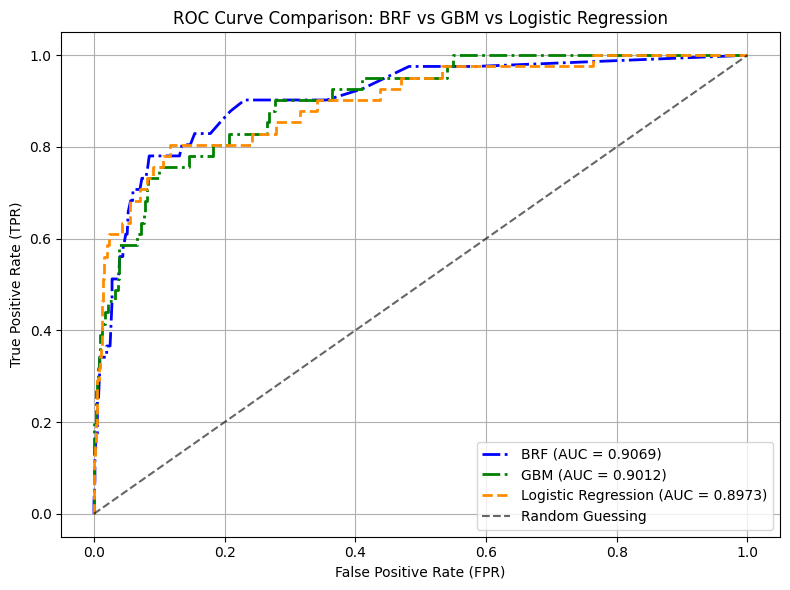

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 📥 로지스틱 회귀 예측 결과 로드
logit_df = pd.read_csv('Final_LogReg_Predictions_Clean.csv')
y_true_logit = logit_df['Label'].astype(int)
y_score_logit = logit_df['Predicted_Probability']

# ✅ BRF/GBM 예측 확률 (다시 생성!)
y_proba_brf = brf.predict_proba(test_input)[:, 1]
y_proba_gbm = gbm.predict_proba(test_input)[:, 1]

# ✅ ROC 계산
fpr_logit, tpr_logit, _ = roc_curve(y_true_logit, y_score_logit)
auc_logit = roc_auc_score(y_true_logit, y_score_logit)

fpr_brf, tpr_brf, _ = roc_curve(test_target, y_proba_brf)
auc_brf = roc_auc_score(test_target, y_proba_brf)

fpr_gbm, tpr_gbm, _ = roc_curve(test_target, y_proba_gbm)
auc_gbm = roc_auc_score(test_target, y_proba_gbm)

# ✅ 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr_brf, tpr_brf, label=f"BRF (AUC = {auc_brf:.4f})", color='blue', linestyle='-.', linewidth=2)
plt.plot(fpr_gbm, tpr_gbm, label=f"GBM (AUC = {auc_gbm:.4f})", color='green', linestyle='-.', linewidth=2)
plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC = {auc_logit:.4f})", color='darkorange', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing", alpha=0.6)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison: BRF vs GBM vs Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ROR 활용
import numpy as np
from scipy.stats import norm
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, average_precision_score
import matplotlib.pyplot as plt

# 📌 ROR Score 계산
X_aug = pd.DataFrame(test_input, columns=input_columns + list(soc_pca_df.columns))
y_aug = test_target

# 📌 유효한 ROR 계산을 위한 작은 epsilon 추가
epsilon = 1e-5
a = X_aug['Feature a'] + epsilon
b = X_aug['Feature b'] + epsilon
c = X_aug['Feature c'] + epsilon
d = X_aug['Feature d'] + epsilon

# 📌 ROR 및 95% CI 하한 계산
ror_score = (a * d) / (b * c)
se_log_ror = np.sqrt(1/a + 1/b + 1/c + 1/d)
log_ror = np.log(ror_score)
log_ci_lower = log_ror - 1.96 * se_log_ror  # 95% CI 하한
ci_lower = np.exp(log_ci_lower)  # log scale → 원래 scale로 변환

# 📌 NaN / Inf 제거
ror_score.replace([np.inf, -np.inf], np.nan, inplace=True)
ci_lower = pd.Series(ci_lower).replace([np.inf, -np.inf], np.nan)
valid_mask = ~ci_lower.isna()

# 📌 예측: 하한값 > 1 → Positive
y_pred_ror_ci = (ci_lower[valid_mask] > 1).astype(int)
y_true_ror = y_aug[valid_mask]

# 📌 평가 지표 출력
print("📌 ROR (95% CI Lower Bound > 1 기준) Classification Report:")
print(classification_report(y_true_ror, y_pred_ror_ci))

precision_ci = precision_score(y_true_ror, y_pred_ror_ci)
recall_ci = recall_score(y_true_ror, y_pred_ror_ci)
f1_ci = f1_score(y_true_ror, y_pred_ror_ci)

print(f"🔹 Precision (CI-based): {precision_ci:.4f}")
print(f"🔹 Recall (CI-based): {recall_ci:.4f}")
print(f"🔹 F1-score (CI-based): {f1_ci:.4f}")


📌 ROR (95% CI Lower Bound > 1 기준) Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1336
           1       0.12      0.46      0.20        41

    accuracy                           0.89      1377
   macro avg       0.55      0.68      0.57      1377
weighted avg       0.96      0.89      0.92      1377

🔹 Precision (CI-based): 0.1250
🔹 Recall (CI-based): 0.4634
🔹 F1-score (CI-based): 0.1969


In [ ]:
# IC 이용방법
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score
)

# 📌 abcd 값 준비
X_aug = pd.DataFrame(test_input, columns=input_columns + list(soc_pca_df.columns))
y_aug = test_target

epsilon = 1e-5
a = X_aug['Feature a'] + epsilon
b = X_aug['Feature b'] + epsilon
c = X_aug['Feature c'] + epsilon
d = X_aug['Feature d'] + epsilon
N = a + b + c + d

# 📌 Expected count under independence
expected = ((a + b) * (a + c)) / N

# 📌 Bayesian Shrinkage 적용한 IC 및 95% CI 계산
a_adj = a + 0.5
expected_adj = expected + 0.5

log_ic = np.log2(a_adj / expected_adj)
se_log_ic = np.sqrt(1 / np.log(2)**2 * (1 / a_adj + 1 / expected_adj))  # 로그 기반 보정

ic025 = log_ic - 1.96 * se_log_ic  # 95% 신뢰구간 하한값

# 📌 NaN / Inf 처리
log_ic = pd.Series(log_ic).replace([np.inf, -np.inf], np.nan)
ic025 = pd.Series(ic025).replace([np.inf, -np.inf], np.nan)
valid_mask = ~ic025.isna()

# 📌 IC025 > 0 이면 Positive
y_pred_ic = (ic025[valid_mask] > 0).astype(int)
y_true_ic = y_aug[valid_mask]

# 📌 평가 지표 출력
print("📌 IC (IC025 > 0 기준) Classification Report:")
print(classification_report(y_true_ic, y_pred_ic))

precision_ic = precision_score(y_true_ic, y_pred_ic)
recall_ic = recall_score(y_true_ic, y_pred_ic)
f1_ic = f1_score(y_true_ic, y_pred_ic)

print(f"🔹 Precision (IC-based): {precision_ic:.4f}")
print(f"🔹 Recall (IC-based): {recall_ic:.4f}")
print(f"🔹 F1-score (IC-based): {f1_ic:.4f}")


📌 IC (IC025 > 0 기준) Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1336
           1       0.24      0.46      0.31        41

    accuracy                           0.94      1377
   macro avg       0.61      0.71      0.64      1377
weighted avg       0.96      0.94      0.95      1377

🔹 Precision (IC-based): 0.2375
🔹 Recall (IC-based): 0.4634
🔹 F1-score (IC-based): 0.3140


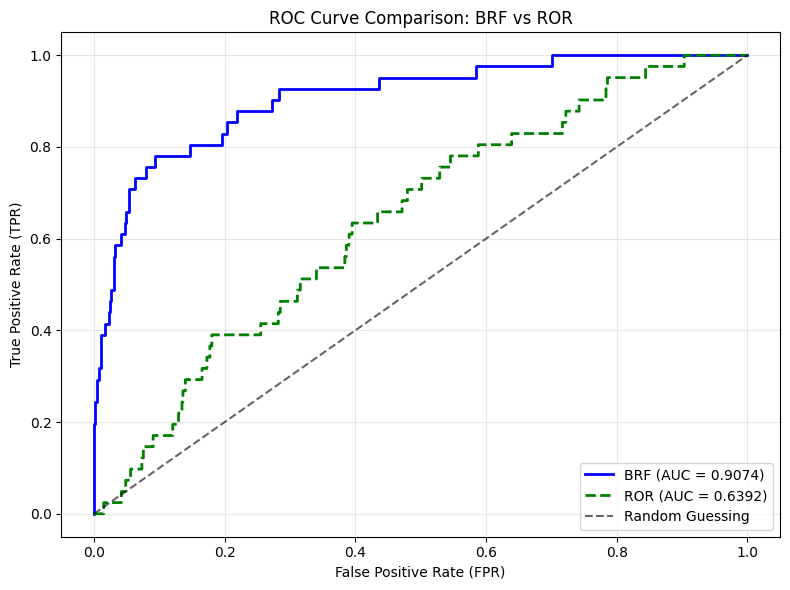

✅ BRF AUC: 0.9074
✅ ROR AUC: 0.6392


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------------------------------------
# 1. ROR 점수 (logROR) 계산하기
# -----------------------------------------------------------
# test_input_aug는 Numpy 배열이므로 인덱스로 접근합니다.
# (Feature a, b, c, d가 각각 0, 1, 2, 3번 컬럼에 위치함)
epsilon = 0.5
feat_a = test_input[:, 0]
feat_b = test_input[:, 1]
feat_c = test_input[:, 2]
feat_d = test_input[:, 3]

# logROR 계산 공식: log((a*d) / (b*c))
# (분모가 0이 되는 것을 막기 위해 epsilon을 더해줍니다)
log_ror_scores = np.log((feat_a + epsilon) * (feat_d + epsilon)) - \
                 np.log((feat_b + epsilon) * (feat_c + epsilon))

# -----------------------------------------------------------
# 2. ROC Curve 좌표 계산 (BRF & ROR)
# -----------------------------------------------------------
# (1) BRF (이미 계산된 y_proba 사용)
fpr_brf, tpr_brf, _ = roc_curve(test_target, y_proba)
auc_brf = roc_auc_score(test_target, y_proba)

# (2) ROR (방금 계산한 log_ror_scores 사용)
fpr_ror, tpr_ror, _ = roc_curve(test_target, log_ror_scores)
auc_ror = roc_auc_score(test_target, log_ror_scores)

# -----------------------------------------------------------
# 3. 그래프 그리기
# -----------------------------------------------------------
plt.figure(figsize=(8, 6))

# BRF Plot
plt.plot(fpr_brf, tpr_brf, label=f"BRF (AUC = {auc_brf:.4f})", color='blue', linewidth=2)

# ROR Plot
plt.plot(fpr_ror, tpr_ror, label=f"ROR (AUC = {auc_ror:.4f})", color='green', linestyle='--', linewidth=2)

# Random Guessing
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing", alpha=0.6)

plt.title("ROC Curve Comparison: BRF vs ROR")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 점수 출력
print(f"✅ BRF AUC: {auc_brf:.4f}")
print(f"✅ ROR AUC: {auc_ror:.4f}")


📌 평가 데이터 샘플 수: 1377
✅ 통계적 점수(ROR/IC Lower Bound) 재계산 완료
▶ Balanced RF AUC: 0.9089
▶ GBM (XGBoost) AUC: 0.9074
▶ ROR (Lower CI) AUC: 0.8055
▶ IC (Lower CI) AUC: 0.8583


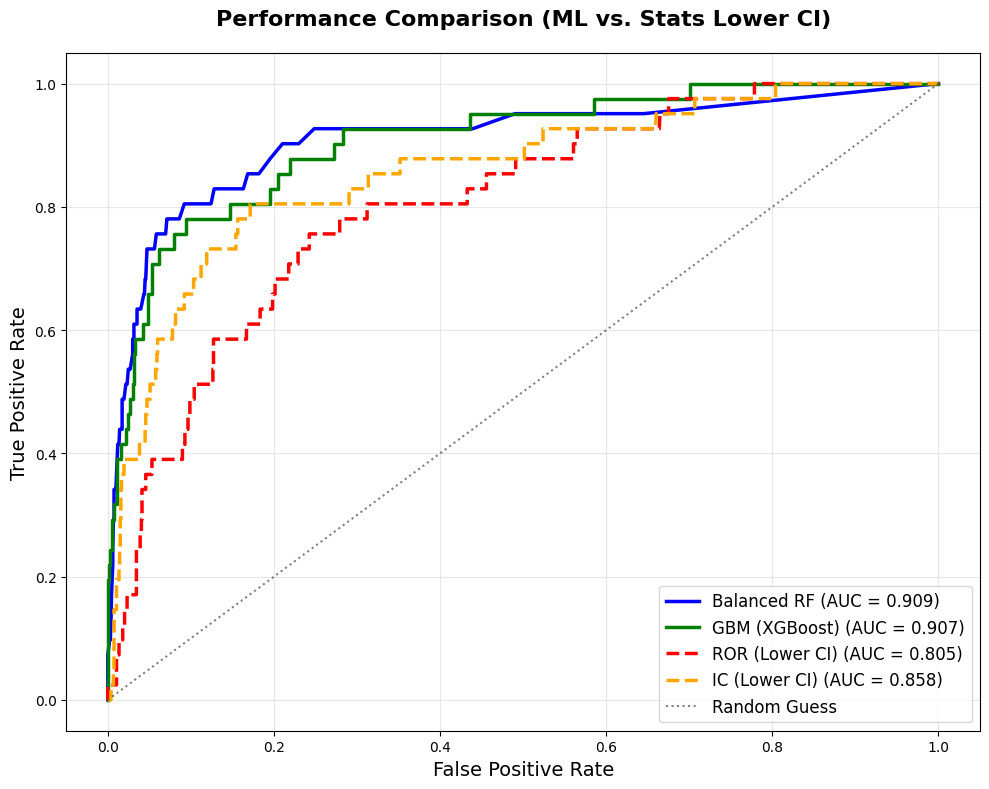

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ==============================================================================
# 1. 데이터 및 모델 준비 (변수 재확인)
# ==============================================================================
# test_input_aug와 test_target_aug가 메모리에 있어야 합니다.
X_eval = test_input
y_eval = test_target

print(f"📌 평가 데이터 샘플 수: {len(y_eval)}")

# ---------------------------------------------------------
# (1) 머신러닝 모델 예측값 (BRF & GBM)
# ---------------------------------------------------------
try:
    y_proba_brf = brf.predict_proba(X_eval)[:, 1]
except NameError:
    y_proba_brf = np.zeros(len(y_eval))
    print("⚠️ BRF 모델 없음")

try:
    y_proba_gbm = gbm.predict_proba(X_eval)[:, 1]
except NameError:
    y_proba_gbm = np.zeros(len(y_eval))
    print("⚠️ GBM 모델 없음")

# ---------------------------------------------------------
# (2) 통계적 방법 점수 계산 (사진 속 기준인 'Lower CI' 활용)
# ---------------------------------------------------------
epsilon = 1e-5

# 컬럼 인덱스 확인 (a,b,c,d가 0,1,2,3번이라고 가정)
a = X_eval[:, 0] + epsilon
b = X_eval[:, 1] + epsilon
c = X_eval[:, 2] + epsilon
d = X_eval[:, 3] + epsilon

# --- [ROR: 95% CI Lower Bound 계산] ---
# 사용자님이 보신 "ROR (95% CI Lower Bound > 1)" 결과와 맞추기 위해
# 단순 ROR 값이 아닌 '신뢰구간 하한값'을 점수(Score)로 사용합니다.
ror_val = (a * d) / (b * c)
log_ror = np.log(ror_val)
se_log_ror = np.sqrt(1/a + 1/b + 1/c + 1/d)
# 하한값 계산 (Log Scale) -> 원래 Scale로 변환하지 않고 Log Scale 그대로 써도 AUC는 동일함
# 하지만 "값이 다르다"는 혼동을 줄이기 위해 Log Lower Bound를 Score로 사용
ror_score_lower_bound = log_ror - 1.96 * se_log_ror

# --- [IC: 95% CI Lower Bound 계산] ---
N = a + b + c + d
expected = ((a + b) * (a + c)) / N
# Bayesian Shrinkage (+0.5)
a_adj = a + 0.5
exp_adj = expected + 0.5
ic_val = np.log2(a_adj / exp_adj)
se_log_ic = np.sqrt(1 / np.log(2)**2 * (1/a_adj + 1/exp_adj))
ic_score_lower_bound = ic_val - 1.96 * se_log_ic

print("✅ 통계적 점수(ROR/IC Lower Bound) 재계산 완료")

# ==============================================================================
# 2. ROC Curve 시각화
# ==============================================================================
plt.figure(figsize=(10, 8))

models = [
    ('Balanced RF', y_proba_brf, 'blue', '-'),
    ('GBM (XGBoost)', y_proba_gbm, 'green', '-'),
    # 점수 자체를 '하한값'으로 변경하여 비교
    ('ROR (Lower CI)', ror_score_lower_bound, 'red', '--'),
    ('IC (Lower CI)', ic_score_lower_bound, 'orange', '--')
]

for name, score, color, style in models:
    if np.sum(score) == 0: continue # 모델 없으면 패스

    fpr, tpr, _ = roc_curve(y_eval, score)
    auc = roc_auc_score(y_eval, score)

    # 📌 여기서 AUC 값을 확인하세요!
    print(f"▶ {name} AUC: {auc:.4f}")

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})",
             color=color, linestyle=style, linewidth=2.5)

# 디자인
plt.plot([0, 1], [0, 1], 'k:', label="Random Guess", alpha=0.5)
plt.title("Performance Comparison (ML vs. Stats Lower CI)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()